In [ ]:
! pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mostafamahmoud12","key":"3cbc2b5589b79058ffe0128348ce9e0c"}'}

In [ ]:
! mkdir ~/.kaggle

In [ ]:
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets list

ref                                                               title                                              size  lastUpdated          downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  ------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
atharvasoundankar/chocolate-sales                                 Chocolate Sales Data 📊🍫                            63KB  2025-03-07 05:44:03           2366         35  1.0              
abdulmalik1518/mobiles-dataset-2025                               Mobiles Dataset (2025)                             20KB  2025-02-18 06:50:24           9205        164  1.0              
asinow/car-price-dataset                                          Car Price Dataset                                 135KB  2025-01-26 19:53:28          26468        416  1.0              
mahmoudelhemaly/students-grading-dataset                    

In [ ]:
#!/bin/bash
! kaggle datasets download virajbagal/roco-dataset

Dataset URL: https://www.kaggle.com/datasets/virajbagal/roco-dataset
License(s): CC0-1.0
  8% 539M/6.19G [00:07<01:22, 73.4MB/s]
User cancelled operation


In [ ]:
! unzip /content/roco-dataset.zip

Archive:  /content/roco-dataset.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/roco-dataset.zip or
        /content/roco-dataset.zip.zip, and cannot find /content/roco-dataset.zip.ZIP, period.


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow.keras.applications import Xception
from keras.applications.xception import preprocess_input
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical ,plot_model
from tensorflow.keras.layers import Input ,Dense ,LSTM ,Embedding ,Dropout ,add
# from datasets import Dataset, DatasetDict
# from datasets import load_dataset


In [ ]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

## `read dataset`

In [ ]:
dataset_path = "/content/all_data"


In [ ]:

def list_images(category, dataset_split):
    """
    category: 'radiology' or 'non-radiology'
    dataset_split: 'train', 'validation', or 'test'
    """
    image_dir = os.path.join(dataset_path, dataset_split, category, "images")
    images = [os.path.join(image_dir, img) for img in os.listdir(image_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]
    return images




In [ ]:
# train datasets
radiology_train_images = list_images("radiology", "train")
print(f"Total radiology training images: {len(radiology_train_images)}")

Total radiology training images: 65420


In [ ]:
# test datasets
radiology_train_images = list_images("radiology", "test")
print(f"Total radiology test images: {len(radiology_train_images)}")

Total radiology test images: 8176


In [ ]:
# validation datasets
radiology_train_images = list_images("radiology", "validation")
print(f"Total radiology validation images: {len(radiology_train_images)}")

Total radiology validation images: 8175


In [ ]:
import pandas as pd
import os

# Define dataset paths
dataset_root = "/content/all_data"
train_csv = os.path.join(dataset_root, "train", "radiologytraindata.csv")
val_csv = os.path.join(dataset_root, "validation", "radiologyvaldata.csv")
test_csv = os.path.join(dataset_root, "test", "radiologytestdata.csv")  # Adjust if needed

# Load datasets
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)


# Combine all datasets
full_dataset = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Save the merged dataset
combined_csv_path = os.path.join(dataset_root, "combined_radiology_dataset.csv")
full_dataset.to_csv(combined_csv_path, index=False)

print(f"Combined dataset saved at: {combined_csv_path}")
print(f"Total records: {len(full_dataset)}")



Combined dataset saved at: /content/all_data/combined_radiology_dataset.csv
Total records: 81809


In [ ]:
full_dataset.head()

,id,name,caption
0,ROCO_00002,PMC4083729_AMHSR-4-14-g002.jpg,Computed tomography scan in axial view showin...
1,ROCO_00003,PMC2837471_IJD2009-150251.001.jpg,Bacterial contamination occurred after comple...
2,ROCO_00004,PMC2505281_11999_2007_30_Fig6_HTML.jpg,The patient had residual paralysis of the han...
3,ROCO_00005,PMC3745845_IJD2013-683423.005.jpg,Panoramic radiograph after immediate loading.\n
4,ROCO_00007,PMC4917066_amjcaserep-17-301-g001.jpg,Plain abdomen x-ray: Multiple air levels at t...


In [ ]:
train_csv = pd.read_csv(os.path.join(dataset_path, "train", "radiologytraindata.csv"))
train_csv.head()

,id,name,caption
0,ROCO_00002,PMC4083729_AMHSR-4-14-g002.jpg,Computed tomography scan in axial view showin...
1,ROCO_00003,PMC2837471_IJD2009-150251.001.jpg,Bacterial contamination occurred after comple...
2,ROCO_00004,PMC2505281_11999_2007_30_Fig6_HTML.jpg,The patient had residual paralysis of the han...
3,ROCO_00005,PMC3745845_IJD2013-683423.005.jpg,Panoramic radiograph after immediate loading.\n
4,ROCO_00007,PMC4917066_amjcaserep-17-301-g001.jpg,Plain abdomen x-ray: Multiple air levels at t...


In [ ]:
import pandas as pd
import os

csv_path = os.path.join(dataset_path, "train", "radiologytraindata.csv")

# Load the CSV file
df = pd.read_csv(csv_path)

# Show first few rows
df.head()


,id,name,caption
0,ROCO_00002,PMC4083729_AMHSR-4-14-g002.jpg,Computed tomography scan in axial view showin...
1,ROCO_00003,PMC2837471_IJD2009-150251.001.jpg,Bacterial contamination occurred after comple...
2,ROCO_00004,PMC2505281_11999_2007_30_Fig6_HTML.jpg,The patient had residual paralysis of the han...
3,ROCO_00005,PMC3745845_IJD2013-683423.005.jpg,Panoramic radiograph after immediate loading.\n
4,ROCO_00007,PMC4917066_amjcaserep-17-301-g001.jpg,Plain abdomen x-ray: Multiple air levels at t...


## ` Filters images based on type`

In [ ]:
def find_images_by_type(df, image_type, dataset_path):
    """
    Filters images based on type (e.g., CT, MRI, X-ray) from the 'caption' column.

    Args:
        df (pd.DataFrame): DataFrame containing image metadata.
        image_type (str): The type of image to search for (e.g., "CT", "X-ray").
        dataset_path (str): Root dataset path.

    Returns:
        List of image file paths matching the type.
    """
    filtered_df = full_dataset[full_dataset["caption"].str.contains(image_type, case=False, na=False)]

    # Get image file names
    image_files = filtered_df["name"].tolist()

    # Convert to full paths
    image_folder = os.path.join(dataset_path, "train", "radiology", "images")
    image_paths = [os.path.join(image_folder, img) for img in image_files]

    return image_paths

# Example Usage
ct_images = find_images_by_type(full_dataset, "CT", dataset_path)
xray_images = find_images_by_type(full_dataset, "X-ray", dataset_path)
mri_images = find_images_by_type(full_dataset, "MRI", dataset_path)

print(f"Total CT images: {len(ct_images)}")
print(f"Total X-ray images: {len(xray_images)}")
print(f"Total MRI images: {len(mri_images)}")


Total CT images: 35237
Total X-ray images: 5355
Total MRI images: 5204


In [ ]:
def find_all_image_types(df):
    """
    Finds all unique image types in the dataset based on common medical terms.

    Args:
        df (pd.DataFrame): DataFrame containing image metadata.

    Returns:
        Dict with image type as key and list of image paths as values.
    """
    image_types = ["CT", "X-ray", "MRI", "Ultrasound", "PET", "Fluoroscopy"]  # Add more if needed
    type_dict = {}

    for img_type in image_types:
        type_dict[img_type] = find_images_by_type(df, img_type, dataset_path)

    return type_dict

# Example: Get all image types
all_images = find_all_image_types(full_dataset)

# Print results
for img_type, img_list in all_images.items():
    print(f"{img_type}: {len(img_list)} images found")


CT: 35237 images found
X-ray: 5355 images found
MRI: 5204 images found
Ultrasound: 2547 images found
PET: 870 images found
Fluoroscopy: 224 images found


## ` Filters only X-ray images and their captions only`

In [ ]:
import pandas as pd
import os

# Define dataset paths
dataset_root = "/content/all_data"
train_csv = os.path.join(dataset_root, "train", "radiologytraindata.csv")
val_csv = os.path.join(dataset_root, "validation", "radiologyvaldata.csv")
test_csv = os.path.join(dataset_root, "test", "radiologytestdata.csv")  # Adjust if needed

# ✅ Load datasets and explicitly add the 'dataset' column
train_df = pd.read_csv(train_csv)
train_df["dataset"] = "train"

val_df = pd.read_csv(val_csv)
val_df["dataset"] = "validation"

test_df = pd.read_csv(test_csv)
test_df["dataset"] = "test"

# ✅ Combine all datasets
full_dataset = pd.concat([train_df, val_df, test_df], ignore_index=True)

# ✅ Save the merged dataset
combined_csv_path = os.path.join(dataset_root, "combined_radiology_dataset.csv")
full_dataset.to_csv(combined_csv_path, index=False)

print(f"✅ Combined dataset saved at: {combined_csv_path}")
print(f"✅ Total records: {len(full_dataset)}")

✅ Combined dataset saved at: /content/all_data/combined_radiology_dataset.csv
✅ Total records: 81809


In [ ]:
def find_xray_images_and_captions(df, dataset_path):
    """
    Filters only X-ray images and their captions from the full dataset.

    Args:
        df (pd.DataFrame): Combined DataFrame containing image metadata.
        dataset_path (str): Root dataset path.

    Returns:
        List of tuples (image_path, caption).
    """
    # ✅ Check if the 'dataset' column exists

    # ✅ Filter rows where the caption contains "x-ray" (handling variations like "x ray" or "X-ray")
    xray_df = df[df["caption"].str.contains(r"\b[xX][- ]?ray\b", case=False, na=False, regex=True)]

    # ✅ Get image file names and captions
    xray_images = xray_df["name"].tolist()
    xray_captions = xray_df["caption"].tolist()

    # ✅ Convert filenames to full paths based on dataset source (train, validation, test)
    xray_paths = []
    for img_name, dataset_type in zip(xray_images, xray_df["dataset"]):
        image_folder = os.path.join(dataset_path, dataset_type, "radiology", "images")
        xray_paths.append(os.path.join(image_folder, img_name))

    return list(zip(xray_paths, xray_captions))


# ✅ Get all X-ray images and captions
xray_data = find_xray_images_and_captions(full_dataset, dataset_root)

print(f"✅ Total X-ray images found: {len(xray_data)}")
for img_path, caption in xray_data[:5]:  # Print first 5 results
    print(f"🖼 Image Path: {img_path}\n📝 Caption: {caption}\n{'-'*80}")

✅ Total X-ray images found: 5419
🖼 Image Path: /content/all_data/train/radiology/images/PMC4917066_amjcaserep-17-301-g001.jpg
📝 Caption:  Plain abdomen x-ray: Multiple air levels at the mid-abdomen (arrows), no radiopaque shadow, and no air under the diaphragm.

--------------------------------------------------------------------------------
🖼 Image Path: /content/all_data/train/radiology/images/PMC5350332_CRIPE2017-6969787.003.jpg
📝 Caption:  AP pelvis X-ray obtained 6 weeks from initial presentation which shows early femoral head collapse.

--------------------------------------------------------------------------------
🖼 Image Path: /content/all_data/train/radiology/images/PMC4891922_12891_2016_1099_Fig3_HTML.jpg
📝 Caption:  X-ray control of calcaneus drilling

--------------------------------------------------------------------------------
🖼 Image Path: /content/all_data/train/radiology/images/PMC4239440_PAMJ-18-217-g001.jpg
📝 Caption:  Free air beneath the diaphragm at abdominal x

In [ ]:
OUTPUT_DIR='/content/working_new'

In [ ]:
import shutil
def save_xray_images_and_captions(xray_data, output_folder):
    """
    Saves X-ray images and their captions in a separate training folder.

    Args:
        xray_data (list): List of tuples (image_path, caption).
        output_folder (str): Destination folder for X-ray images and captions.
    """
    os.makedirs(output_folder, exist_ok=True)  # Create folder if not exists

    captions_file = os.path.join(output_folder, "captions.txt")

    with open(captions_file, "w", encoding="utf-8") as f:
        for img_path, caption in xray_data:
            if os.path.exists(img_path):
                # Copy image to new folder
                shutil.copy(img_path, output_folder)

                # Write caption to file
                f.write(f"{os.path.basename(img_path)}\t{caption}\n")

# Define the new folder for X-ray training data
xray_output_folder = os.path.join(OUTPUT_DIR, "train", "xray_dataset_NEW")

# Save X-ray images and captions
save_xray_images_and_captions(xray_data, xray_output_folder)

print(f"Saved {len(xray_data)} X-ray images and captions to {xray_output_folder}")


Saved 5419 X-ray images and captions to /content/working_new/train/xray_dataset_NEW


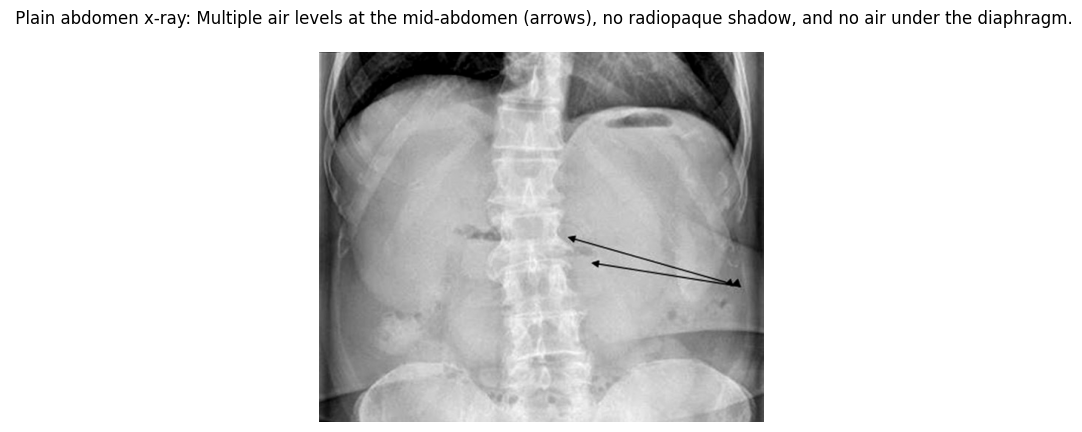

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def show_sample_xray(xray_data):
    """Displays a sample X-ray image with its caption."""
    if not xray_data:
        print("No X-ray images found!")
        return

    img_path, caption = xray_data[0]
    img = Image.open(img_path)

    plt.imshow(img, cmap="gray")  # Medical images are usually grayscale
    plt.axis("off")
    plt.title(caption)
    plt.show()

# Show a sample X-ray image
show_sample_xray(xray_data)


In [ ]:
import os
import pandas as pd

# Define the dataset folder
xray_dataset_path = "/content/working_new/train/xray_dataset_NEW"
captions_file = os.path.join(xray_dataset_path, "captions.txt")

# Read the captions file
captions = pd.read_csv(captions_file, sep="\t", names=["image_name", "caption"])

# Add full image paths
captions["image_path"] = captions["image_name"].apply(lambda x: os.path.join(xray_dataset_path, x))

# Show first few rows
captions.head()


,image_name,caption,image_path
0,PMC4917066_amjcaserep-17-301-g001.jpg,Plain abdomen x-ray: Multiple air levels at t...,/content/working_new/train/xray_dataset_NEW/PM...
1,PMC5350332_CRIPE2017-6969787.003.jpg,AP pelvis X-ray obtained 6 weeks from initial...,/content/working_new/train/xray_dataset_NEW/PM...
2,PMC4891922_12891_2016_1099_Fig3_HTML.jpg,X-ray control of calcaneus drilling,/content/working_new/train/xray_dataset_NEW/PM...
3,PMC4239440_PAMJ-18-217-g001.jpg,Free air beneath the diaphragm at abdominal x...,/content/working_new/train/xray_dataset_NEW/PM...
4,PMC4546967_CRIOR2015-301949.003.jpg,X-ray arthrogram showing mild contrast tracki...,/content/working_new/train/xray_dataset_NEW/PM...


In [ ]:
len(captions)

5417

## `PreProssing in images and Extract features for images`

In [ ]:
image_paths='/content/working_new/train/xray_dataset_NEW'

In [ ]:
def show_image_size(image_path):
    """Displays the size of an image before and after resizing."""
    with Image.open(image_path) as img:
        print(f"Original size: {img.size}")  # Print original size
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(f"Original Size: {img.size}")
        plt.show()


Original size: (600, 499)


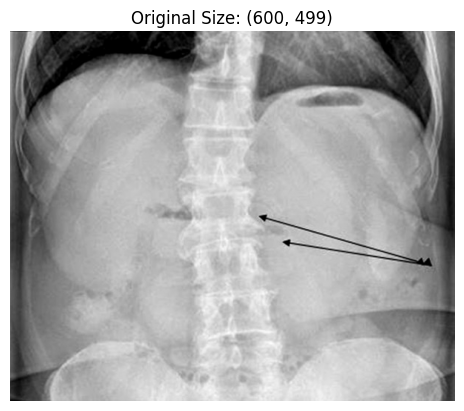

Resized size: (256, 256)


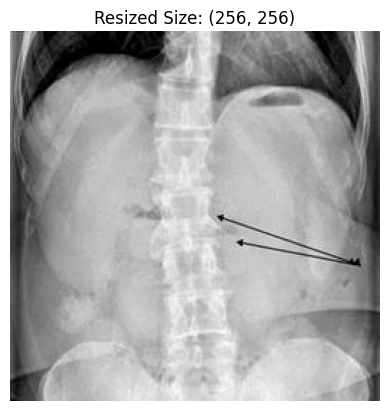

Resized images saved to: /content/working/train/xray_dataset_resized


In [ ]:

def resize_images_and_show(image_paths, output_folder, output_size=(256, 256)):
    """
    Resizes images, saves them to a new folder, and displays before/after sizes.

    Args:
        image_paths (list): List of image file paths.
        output_folder (str): Folder to save resized images.
        output_size (tuple): Target image size (width, height).
    """
    os.makedirs(output_folder, exist_ok=True)

    for img_path in image_paths:
        if os.path.exists(img_path):
            try:
                with Image.open(img_path) as img:
                    # Show original size
                    show_image_size(img_path)

                    # Resize the image
                    img = img.resize(output_size, Image.LANCZOS)

                    # Save to new folder
                    new_img_path = os.path.join(output_folder, os.path.basename(img_path))
                    img.save(new_img_path)

                    # Show new size
                    with Image.open(new_img_path) as resized_img:
                        print(f"Resized size: {resized_img.size}")  # Print new size
                        plt.imshow(resized_img, cmap="gray")
                        plt.axis("off")
                        plt.title(f"Resized Size: {resized_img.size}")
                        plt.show()

                    # Stop after one sample for display (remove this to show all)
                    break

            except Exception as e:
                print(f"Error processing {img_path}: {e}")

# Define the folder for resized images
resized_folder = os.path.join(OUTPUT_DIR, "train", "xray_dataset_resized")

# Apply resizing and show before/after sizes
resize_images_and_show([img_path for img_path, _ in xray_data], resized_folder)

print(f"Resized images saved to: {resized_folder}")


In [ ]:
OUTPUT_DIR_OF_IMAGES='/content/working_new/train'

## `load caption`

In [ ]:
captions['caption'][100]

' Chest X-ray performed after transplantation. Two drains inserted in right pleural cavity and catheter in right carotid internal vein are visible'

In [ ]:
len(captions)

5417

In [ ]:
import pandas as pd
from tqdm import tqdm

def extract_captions(df):
    """
    Extracts image captions from a DataFrame and organizes them by image ID.

    Args:
        df (pd.DataFrame): DataFrame containing image metadata.

    Returns:
        dict: Dictionary where keys are image IDs and values are lists of captions.
    """
    captions_img = {}

    # Iterate over rows in the DataFrame
    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            img_id = row["image_name"].split('.')[0]  # Remove file extension
            caption = row["caption"]  # Extract caption text

            # Store in dictionary
            if img_id not in captions_img:
                captions_img[img_id] = []
            captions_img[img_id].append(caption)

        except Exception as e:
            print(f"Skipping row due to error: {e}")

    return captions_img





# Extract captions
captions_dict = extract_captions(captions)

# Show first 5 entries
for img_id, captions in list(captions_dict.items())[:5]:
    print(f"Image ID: {img_id}\nCaptions: {captions}\n{'-'*80}")


100%|██████████| 5417/5417 [00:00<00:00, 27338.15it/s]


Image ID: PMC4917066_amjcaserep-17-301-g001
Captions: [' Plain abdomen x-ray: Multiple air levels at the mid-abdomen (arrows), no radiopaque shadow, and no air under the diaphragm.']
--------------------------------------------------------------------------------
Image ID: PMC5350332_CRIPE2017-6969787
Captions: [' AP pelvis X-ray obtained 6 weeks from initial presentation which shows early femoral head collapse.', ' AP pelvis X-ray showing avascular changes of subchondral cystic lucency without evidence of femoral head collapse.', ' Frog leg lateral X-ray of bilateral hips again showing avascular changes with characteristic “crescent sign” of osteonecrosis to right femoral head.', ' AP pelvis X-ray obtained 12 weeks from initial presentation with progressive flattening of femoral epiphysis indicative of segmental collapse seen in non-Perthes osteonecrosis.']
--------------------------------------------------------------------------------
Image ID: PMC4891922_12891_2016_1099_Fig3_HTML
C

In [ ]:
import nltk

# Download required resources
nltk.download("punkt")       # Tokenizer
nltk.download("stopwords")   # Stop words list
nltk.download("wordnet")     # WordNet dictionary (Fixes the error)
nltk.download("averaged_perceptron_tagger")  # POS tagging (needed for correct lemmatization

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
import nltk

# Set an alternate NLTK data directory (your home folder)
nltk.data.path.append('/kaggle/working/')

# Download stopwords and WordNet to this location
nltk.download('stopwords', download_dir='/kaggle/working/')
nltk.download('wordnet', download_dir='/kaggle/working/')


[nltk_data] Downloading package stopwords to /kaggle/working/...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /kaggle/working/...


True

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean(captions_img):
    """
    Cleans and normalizes captions by lowercasing, removing non-alphabetic characters,
    removing stopwords, lemmatizing, and adding start/end tokens.

    Args:
        captions_img (dict): Dictionary where keys are image IDs and values are lists of captions.

    Returns:
        dict: Cleaned captions dictionary.
    """
    for key, captions in captions_img.items():
        for i in range(len(captions)):
            caption = captions[i]

            # Lowercase the text
            caption = caption.lower()

            # Remove non-alphabet characters (except spaces)
            caption = re.sub(r'[^a-z\s]', '', caption)

            # Remove extra spaces
            caption = re.sub(r'\s+', ' ', caption).strip()

            # Tokenize words
            words = caption.split()

            # Remove stopwords & lemmatize
            words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

            # Reconstruct caption with start/end tokens
            caption = f"startseq {' '.join(words)} endseq"

            # Update the list
            captions[i] = caption

    return captions_img

# Example Usage
cleaned_captions = clean(captions_dict)

# Show first 5 cleaned captions
for img_id, captions in list(cleaned_captions.items())[:5]:
    print(f"Image ID: {img_id}\nCleaned Captions: {captions}\n{'-'*80}")


Image ID: PMC4917066_amjcaserep-17-301-g001
Cleaned Captions: ['startseq plain abdomen xray multiple air level midabdomen arrow radiopaque shadow air diaphragm endseq']
--------------------------------------------------------------------------------
Image ID: PMC5350332_CRIPE2017-6969787
Cleaned Captions: ['startseq ap pelvis xray obtained week initial presentation show early femoral head collapse endseq', 'startseq ap pelvis xray showing avascular change subchondral cystic lucency without evidence femoral head collapse endseq', 'startseq frog leg lateral xray bilateral hip showing avascular change characteristic crescent sign osteonecrosis right femoral head endseq', 'startseq ap pelvis xray obtained week initial presentation progressive flattening femoral epiphysis indicative segmental collapse seen nonperthes osteonecrosis endseq']
--------------------------------------------------------------------------------
Image ID: PMC4891922_12891_2016_1099_Fig3_HTML
Cleaned Captions: ['start

In [ ]:
cleaned_captions['PMC5350332_CRIPE2017-6969787']

['startseq ap pelvis xray obtained week initial presentation show early femoral head collapse endseq',
 'startseq ap pelvis xray showing avascular change subchondral cystic lucency without evidence femoral head collapse endseq',
 'startseq frog leg lateral xray bilateral hip showing avascular change characteristic crescent sign osteonecrosis right femoral head endseq',
 'startseq ap pelvis xray obtained week initial presentation progressive flattening femoral epiphysis indicative segmental collapse seen nonperthes osteonecrosis endseq']

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Step 1: Prepare captions data for tokenization

all_captions = []
for captions in cleaned_captions.values():
    all_captions.extend(captions)




In [ ]:
all_captions[:10]

['startseq plain abdomen xray multiple air level midabdomen arrow radiopaque shadow air diaphragm endseq',
 'startseq ap pelvis xray obtained week initial presentation show early femoral head collapse endseq',
 'startseq ap pelvis xray showing avascular change subchondral cystic lucency without evidence femoral head collapse endseq',
 'startseq frog leg lateral xray bilateral hip showing avascular change characteristic crescent sign osteonecrosis right femoral head endseq',
 'startseq ap pelvis xray obtained week initial presentation progressive flattening femoral epiphysis indicative segmental collapse seen nonperthes osteonecrosis endseq',
 'startseq xray control calcaneus drilling endseq',
 'startseq free air beneath diaphragm abdominal xray film endseq',
 'startseq xray arthrogram showing mild contrast tracking along proximal lateral aspect femoral component endseq',
 'startseq pelvic xray hour ct showed gastric band connecting tube lower pelvis endseq',
 'startseq chest xray confi

In [ ]:
# Step 2: Tokenize captions
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vcab_size = len(tokenizer.word_index)+1

In [ ]:
vcab_size

5839

In [ ]:
# Tokenizer
tokenizer = Tokenizer(num_words=vcab_size, oov_token="<UNK>")
tokenizer.fit_on_texts([" ".join(captions) for captions in cleaned_captions.values()])

In [ ]:
# Convert text to sequences
sequences = tokenizer.texts_to_sequences([" ".join(captions) for captions in cleaned_captions.values()])


In [ ]:
# Step 4: Find max sequence length
max_length = max(len(seq) for seq in sequences)

In [ ]:
max_length

136

In [ ]:
# Pad sequences
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding="post")


In [ ]:
# Step 6: Create Embedding Layer
embedding_dim = 300  # Size of word vectors (e.g., 100, 200, 300)
embedding_layer = Embedding(input_dim=vcab_size, output_dim=embedding_dim, input_length=max_length)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
print(f"✅ Embedding layer created with vocab size {vcab_size} and max length {max_length}.")


✅ Embedding layer created with vocab size 5839 and max length 136.


In [ ]:
# Convert to numpy array (dummy embeddings for now)
embedding_matrix = np.random.rand(vcab_size, embedding_dim)

In [ ]:
# Save the tokenizer
tokenizer_path = "tokenizer.pkl"
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

# Save the embedding matrix
embedding_matrix_path = "embedding_matrix.npy"
np.save(embedding_matrix_path, embedding_matrix)

print(f"Tokenizer saved to: {tokenizer_path}")
print(f"Embedding matrix saved to: {embedding_matrix_path}")


Tokenizer saved to: tokenizer.pkl
Embedding matrix saved to: embedding_matrix.npy


In [ ]:
# train test split

image_ids = list(captions_dict.keys())
split = int(len(image_ids)*0.95)
split

4962

In [ ]:
train = image_ids[ : split]
test = image_ids[split : ]

In [ ]:
len(train)

4962

In [ ]:
len(test)

262

# GAN Model

In [ ]:
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Input, Embedding, Dense, Flatten, Reshape, Conv2D, Conv2DTranspose, LeakyReLU, Softmax
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [ ]:
import pickle
import numpy as np

# Split dataset (95% Train, 5% Test)
image_ids = list(captions_dict.keys())
split = int(len(image_ids) * 0.95)

train_ids = image_ids[:split]
test_ids = image_ids[split:]

print(f"Training Samples: {len(train_ids)}, Testing Samples: {len(test_ids)}")


Training Samples: 4962, Testing Samples: 262


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Load embedding matrix
embedding_matrix = np.load("embedding_matrix.npy")

# Get vocabulary size and max sequence length
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(seq) for seq in tokenizer.texts_to_sequences([" ".join(captions) for captions in captions_dict.values()]))

print(f"Vocabulary Size: {vocab_size}, Max Length: {max_length}")


Vocabulary Size: 5840, Max Length: 136


In [ ]:
# Convert captions to sequences
train_sequences = tokenizer.texts_to_sequences([" ".join(captions_dict[i]) for i in train_ids])
test_sequences = tokenizer.texts_to_sequences([" ".join(captions_dict[i]) for i in test_ids])

# Pad sequences
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding="post")
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding="post")

print(f"Train Shape: {train_padded.shape}, Test Shape: {test_padded.shape}")


Train Shape: (4962, 136), Test Shape: (262, 136)


In [ ]:
image_path='/content/working_new/train/xray_dataset_NEW'

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Define Image Size for Model
IMG_SIZE = (256, 256)

def preprocess_image(image_path):
    """Load and preprocess an image if it exists."""
    if not os.path.exists(image_path):
        print(f"⚠️ Warning: File not found: {image_path}")
        return None  # Skip missing files
    img = load_img(image_path, target_size=IMG_SIZE)  # Resize image
    img = img_to_array(img) / 255.0  # Normalize pixel values
    return img

# Define X-ray image directory
xray_dir = "/content/working_new/train/xray_dataset_NEW"

# Get all image filenames (assuming they are JPG/PNG files)
image_filenames = [f for f in os.listdir(xray_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

# Load and preprocess all X-ray images
xray_images = [preprocess_image(os.path.join(xray_dir, img)) for img in image_filenames]

# Remove None values (skipping missing files)
xray_images = np.array([img for img in xray_images if img is not None])

print(f"✅ Loaded {len(xray_images)} X-ray images")
print(f"📏 Image Data Shape: {xray_images.shape}")


✅ Loaded 5417 X-ray images
📏 Image Data Shape: (5417, 256, 256, 3)


In [ ]:
from tensorflow.keras.layers import Layer, Dense, Softmax

class CrossAttention(Layer):
    def __init__(self, embed_dim):
        super(CrossAttention, self).__init__()
        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.softmax = Softmax(axis=-1)

    def call(self, query, key, value):
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        attention_scores = tf.matmul(query, key, transpose_b=True)
        attention_weights = self.softmax(attention_scores)
        attention_output = tf.matmul(attention_weights, value)

        return attention_output


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2DTranspose, Reshape, Flatten

# Encoder for text
def text_encoder(vocab_size, embedding_dim, max_length):
    inputs = Input(shape=(max_length,))
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length)(inputs)
    encoded_text = Flatten()(embedding)
    model = Model(inputs, encoded_text, name="TextEncoder")
    return model

# Generator with Cross-Attention
def attn_gan_generator():
    text_input = Input(shape=(max_length,))
    image_input = Input(shape=(256, 256, 3))

    # Text encoder
    text_encoder_model = text_encoder(vocab_size, embedding_dim, max_length)
    text_features = text_encoder_model(text_input)

    # Apply Cross-Attention
    attention = CrossAttention(embed_dim=256)(text_features, text_features, text_features)

    # Upsample Image
    x = Conv2DTranspose(128, (3,3), activation='relu', padding='same')(image_input)
    x = Conv2DTranspose(64, (3,3), activation='relu', padding='same')(x)
    x = Conv2DTranspose(3, (3,3), activation='sigmoid', padding='same')(x)

    generator = Model([text_input, image_input], x, name="AttnGAN_Generator")
    return generator

generator = attn_gan_generator()
generator.summary()


Model: "AttnGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_3        │ (None, 256, 256, 128)  │          3,584 │ input_layer_4[0][0]    │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_4        │ (None, 256, 256, 64)   │         73,792 │ conv2d_transpose_3[0]… │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_3             │ (None, 136)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_5        │ (None, 256, 256, 3)    │          1,731 │ conv2d_transpose_4[0]… │
│ (Conv2DTranspose)         │                        │                │                        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 79,107 (309.01 KB)

 Trainable params: 79,107 (309.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.layers import Conv2D, LeakyReLU

def attn_gan_discriminator():
    image_input = Input(shape=(256, 256, 3))

    x = Conv2D(64, (3,3), strides=(2,2), padding='same')(image_input)
    x = LeakyReLU()(x)

    x = Conv2D(128, (3,3), strides=(2,2), padding='same')(x)
    x = LeakyReLU()(x)

    x = Flatten()(x)
    output = Dense(1, activation='sigmoid')(x)

    discriminator = Model(image_input, output, name="AttnGAN_Discriminator")
    return discriminator

discriminator = attn_gan_discriminator()
discriminator.summary()


Model: "AttnGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 524288)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │         524,289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 599,937 (2.29 MB)

 Trainable params: 599,937 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_ids = image_ids[:split]  # Training data
test_ids = image_ids[split:]   # Testing data


### Train Gans

In [ ]:
# Compile Models
generator.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy")
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy")

# Create GAN Model
discriminator.trainable = False
text_input = Input(shape=(max_length,))
image_input = Input(shape=(256, 256, 3))
generated_image = generator([text_input, image_input])
gan_output = discriminator(generated_image)
gan_model = Model([text_input, image_input], gan_output)
gan_model.compile(loss="binary_crossentropy", optimizer=Adam(0.0002, 0.5))

# Training Loop
EPOCHS = 5
BATCH_SIZE = 32

for epoch in range(EPOCHS):
    for i in range(0, len(train_ids), BATCH_SIZE):
        batch_images = np.array([xray_images[i % len(xray_images)] for i in range(i, i + BATCH_SIZE)])
        batch_captions = np.array([train_padded[i % len(train_padded)] for i in range(i, i + BATCH_SIZE)])

        # Generate Fake Images
        generated_images = generator.predict([batch_captions, batch_images])

        # Train Discriminator
        real_labels = np.ones((BATCH_SIZE, 1)) * 0.9
        fake_labels = np.zeros((BATCH_SIZE, 1)) + 0.1
        d_loss_real = discriminator.train_on_batch(batch_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(generated_images, fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train Generator
        g_loss = gan_model.train_on_batch([batch_captions, batch_images], real_labels)

    print(f"Epoch {epoch+1}/{EPOCHS} - D Loss: {d_loss:.4f} - G Loss: {g_loss:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Save trained models
generator.save("generator_model.h5")
discriminator.save("discriminator_model.h5")
gan_model.save("gan_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


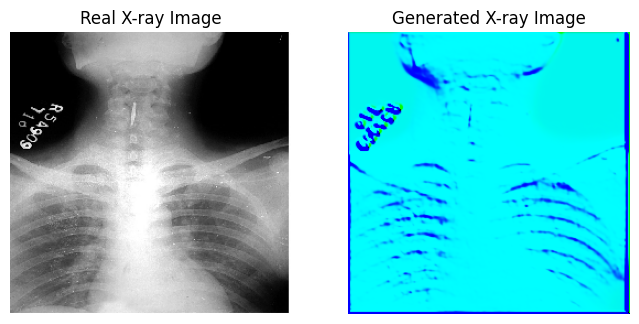

In [ ]:
import matplotlib.pyplot as plt

# Number of images to generate
num_samples = 5  # Adjust as needed

# Select test samples
test_captions_sample = test_padded[:num_samples]
test_images_sample = xray_images[:num_samples]  # If using images for conditioning

# Generate images
generated_images = generator.predict([test_captions_sample, test_images_sample])

# Plot results
fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 3))

for i in range(num_samples):
    axes[i, 0].imshow(test_images_sample[i])  # Original X-ray image
    axes[i, 0].set_title("Real Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(generated_images[i])  # Generated Image
    axes[i, 1].set_title("Generated Image")
    axes[i, 1].axis("off")

plt.show()


In [ ]:
# Predict if the generated image is real or fake
prediction = discriminator.predict(np.expand_dims(generated_image, axis=0))

# Display result
if prediction > 0.5:
    print("✅ Discriminator thinks this is a REAL X-ray.")
else:
    print("❌ Discriminator thinks this is a FAKE X-ray.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
✅ Discriminator thinks this is a REAL X-ray.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


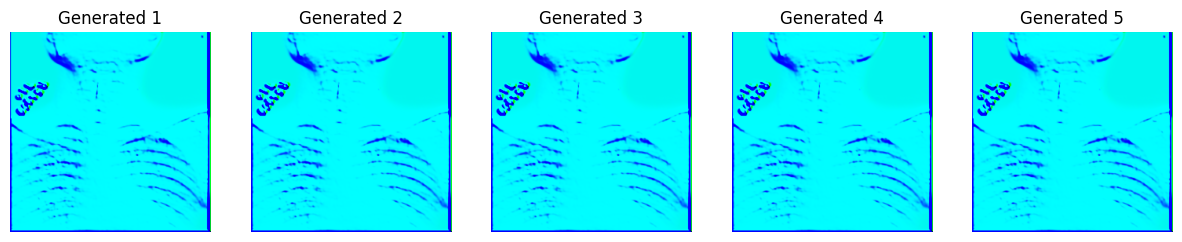

In [ ]:
# Generate multiple images for the same text
num_samples = 5
fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for i in range(num_samples):
    generated_image = generator.predict([np.expand_dims(test_caption, axis=0), np.expand_dims(test_image, axis=0)])
    generated_image = np.clip(generated_image[0], 0, 1)

    axes[i].imshow(generated_image)
    axes[i].axis("off")
    axes[i].set_title(f"Generated {i+1}")

plt.show()
